### This is assuming noon time radiation: worst case scene

In [6]:
#Added a fraction that would allow the background to be evaluated as a fraction based on orbit/time.

import numpy as np
import math as m

# Parameters for 2x2 superpexel
E_refl = 0.21467         # Max relfected Solar irradiance [W/m^2/nm] at normal incidence (TOA)
E_refl_nt = 0.0034       # Night relfected irradiance [W/m^2/nm] at normal incidence (TOA)
iFOV_bandpass  = 0.32    # Max wavelength range is 10.02 nm, iFOV bandpass is for 2x2 pixels constituting the superpixel
Back_Fraction = 1        # Background fraction depending on background photons relative to noon time (0-1)     
tel_dia = 0.6            # in m
Alt     = 474e3          # Altitude of spacecraft [m]
lambda_nm = 1040         # Wavelength for photon-rate estimate [nm]
Counting_wind = 160e-9   # Time window for counting / accumulating background [s]
spot_per_pixel = 16      # in m, derived from 4µm on detector for each meter on ground. Pixel is 64µm across
pix_per_superpix = 4     # in m, derived from 4µm on detector for each meter on ground. Pixel is 64µm across

Dark_Power_NEP = 0.75e-15# 0.75fW/√Hz, as rms ASD value per Greg C
QE = 0.75                # for modelling per Greg

# Constants
h = 6.62607015e-34       # Planck constant [J s]
c = 2.99792458e8         # Speed of light [m/s]

# Calculations

# Area of ground on each super pixel (pixel is a 64x64µm square)
A_spot_pix = pix_per_superpix * spot_per_pixel**2 

# Radiance of a Lambertian surface: L = E_refl * Wave_range / pi
L = (E_refl * iFOV_bandpass)   # [W m^-2 sr^-1]

# Radiance of a night Lambertian surface: L = E_refl * Wave_range / pi
Lnt = (E_refl_nt * iFOV_bandpass)   # [W m^-2 sr^-1]

# Area of telescope
A_tel = np.pi*(tel_dia/2)**2   # Detector (or lens) area [m^2] (in reality there should be some margin for M2 geometry)

# Solid angle subtended by telescope of area A_det at distance Alt
Omega = A_tel / Alt**2       # [sr]

# Power reaching pixel
P_pix = L * A_tel * Omega * A_spot_pix * Back_Fraction # [W]

# Power reaching pixel at night
P_pix_nt = Lnt * A_tel * Omega * A_spot_pix * Back_Fraction # [W]

# Photon energy
lambda_m = lambda_nm * 1e-9
E_photon = (h * c) / lambda_m  # [J]

# Photon rate
photon_rate = P_pix / E_photon  # [photons/s]

# Photon rate at night
photon_rate_nt = P_pix_nt / E_photon  # [photons/s]

# Number of photons in one counting window
photon_wind = photon_rate * Counting_wind

# Number of photons at night in one counting window
photon_wind_nt = photon_rate_nt * Counting_wind

# Dark Photons from NEP (rms ASD value) from Greg
Dark_Photons_NEP =  (QE * Dark_Power_NEP / E_photon)**2/2  # rms ASD to per second

# Number of dark photons in one counting window
Dark_photon_wind = Dark_Photons_NEP * Counting_wind

# Output
print("-- Reflection Solar Illumination Result --")
print(f"Max relfected  irradiance: {E_refl:.2f} W/m^2/nm")
print(f"Night time irradiance    : {E_refl_nt:.4f} W/m^2/nm")
print(f"iFOV_bandpass ∆λ_ifov    : {iFOV_bandpass} nm")
print(f"Radiance (L)             : {L:.3f} W/(m²·sr)")
print(f"Telescope area           : {A_tel:.4f} m²")
print(f"Distance to surface      : {Alt:.2f} m")
print(f"Solid angle (Ω)          : {Omega:.3e} sr")
print(f"Power on pixel           : {P_pix:.3e} W")
print(f"Photon wavelength        : {lambda_nm} nm")
print(f"Photon energy            : {E_photon:.3e} J")
print(f"Photon rate              : {photon_rate:.3e} photons/s")
print(f"Number of Photons        : {photon_wind:.3} photons within {Counting_wind*1e9} ns window")
print(f"Night Photon rate        : {photon_rate_nt:.3e} photons/s")
print(f"Number of Photons at night:{photon_wind_nt:.3} photons within {Counting_wind*1e9} ns window")
print(f"Dark Photon rate from NEP: {Dark_Photons_NEP:.3e} photons/s")
print(f"Number of Dark Photons   : {Dark_photon_wind:.3} photons within {Counting_wind*1e9} ns window")


-- Reflection Solar Illumination Result --
Max relfected  irradiance: 0.21 W/m^2/nm
Night time irradiance    : 0.0034 W/m^2/nm
iFOV_bandpass ∆λ_ifov    : 0.32 nm
Radiance (L)             : 0.069 W/(m²·sr)
Telescope area           : 0.2827 m²
Distance to surface      : 474000.00 m
Solid angle (Ω)          : 1.258e-12 sr
Power on pixel           : 2.503e-11 W
Photon wavelength        : 1040 nm
Photon energy            : 1.910e-19 J
Photon rate              : 1.310e+08 photons/s
Number of Photons        : 21.0 photons within 160.0 ns window
Night Photon rate        : 2.075e+06 photons/s
Number of Photons at night:0.332 photons within 160.0 ns window
Dark Photon rate from NEP: 4.336e+06 photons/s
Number of Dark Photons   : 0.694 photons within 160.0 ns window


In [8]:
import numpy as np
c = 299792458  # speed of light in m/s

# Vertical resolution from FWHM

samples_per_waveform_Tx = 20        #(20 for Tx,need to capture sent out and pulse shape accounting for jitter)
Pulse_FWHM = 2                      # 2 ns

# Conversion constants for a Gaussian
FWHM_to_1e2 = np.sqrt(2 / np.log(2))      # multiply FWHM to get 1/e^2 width

def fwhm_to_1e2(fwhm):
    #Convert FWHM to 1/e^2 full width (Gaussian)
    return fwhm * FWHM_to_1e2

# Parameters
fwhm = 2.0  # arbitrary units
e2_width = fwhm_to_1e2(fwhm)

# Resolution
Time_resolution = e2_width / samples_per_waveform_Tx
Space_resolution = Time_resolution * 10**-9 * c *100 / 2

print(f"FWHM              = {fwhm}")
print(f"1/e^2 width       = {e2_width:.4f}")
print(f"Timing resolution = {Time_resolution:.4f} ns")
print(f"Timing resolution = {Space_resolution:.4f} cm")

FWHM              = 2.0
1/e^2 width       = 3.3973
Timing resolution = 0.1699 ns
Timing resolution = 2.5462 cm


The Figure and table below for the HgCdTe detector from DRS is from Sun, Xiaoli. 2024. "Review of Photodetectors for Space Lidars" Review of Photodetectors for Space Lidars, Sensors 2024, 24, 6620. https://doi.org/10.3390/s24206620

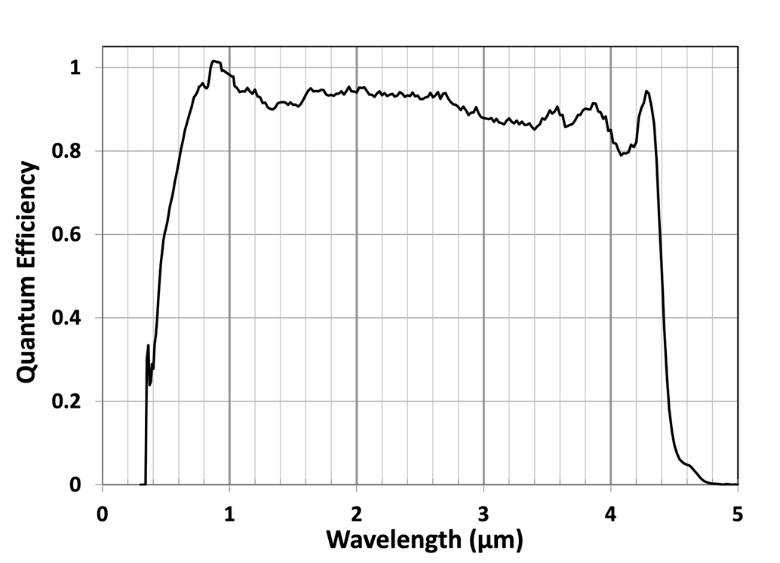

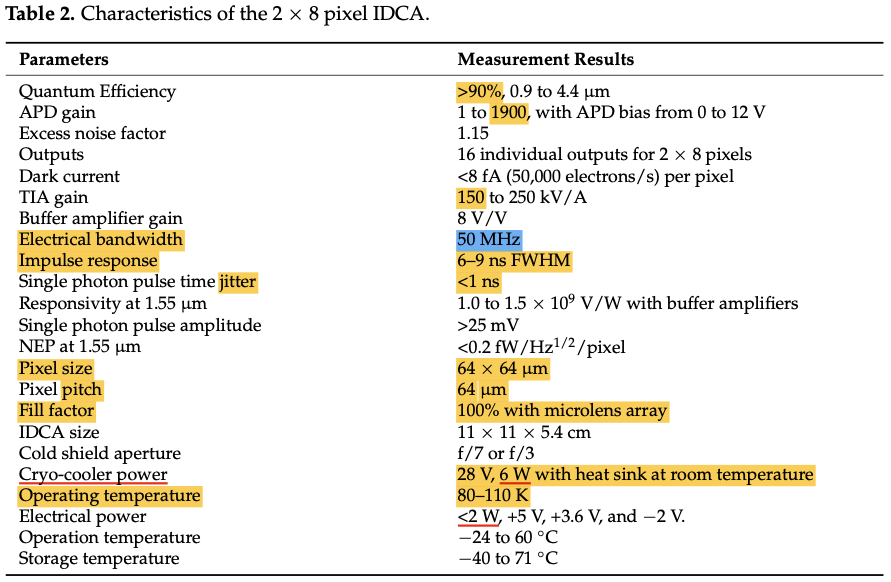

The page below shows the no dead time for the detectors based on Sullivan, W., Beck, J., Scritchfield, . et al. Linear-Mode HgCdTe Avalanche Photodiodes for Photon-Counting Applications. J. Electron. Mater. 44, 3092–3101 (2015). https://doi.org/10.1007/s11664-015-3824-3

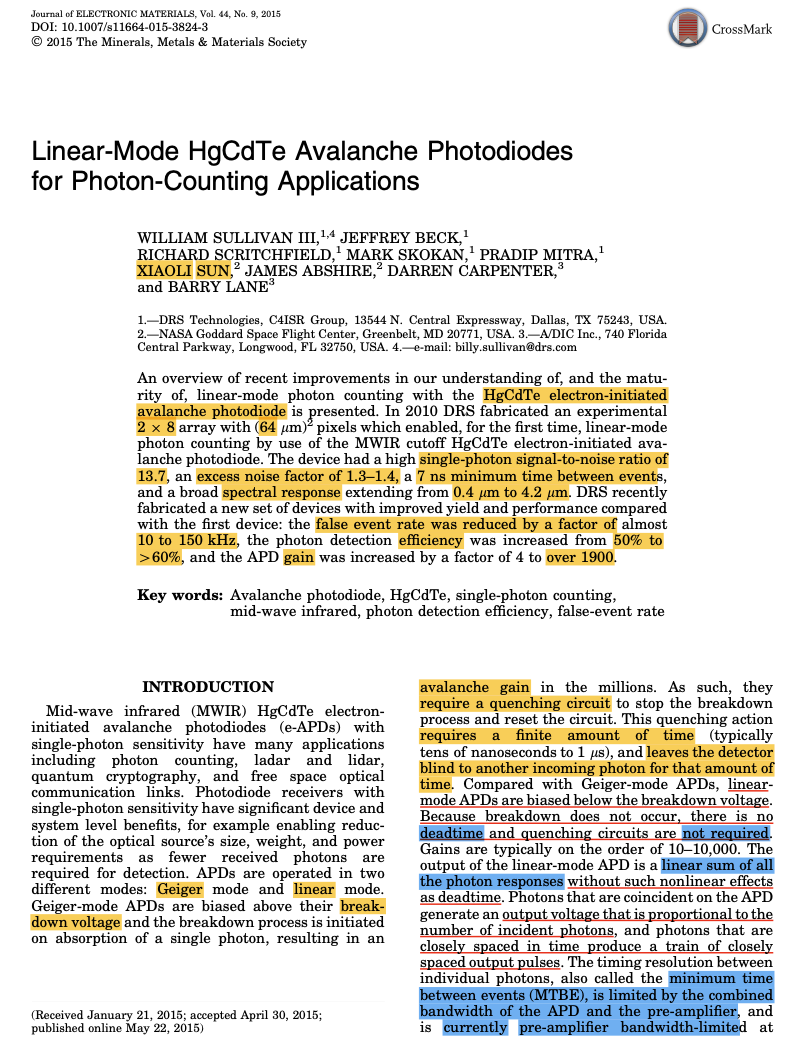

 #### Evaluate the parameters for timing resolution of Tx pulse

In [9]:
import numpy as np
c = 299792458  # speed of light in m/s

# Vertical resolution from FWHM

samples_per_waveform_Tx = 20        #(20 for Tx,need to capture sent out and pulse shape accounting for jitter)
Pulse_FWHM = 2                      # 2 ns

# Conversion constants for a Gaussian
FWHM_to_1e2 = np.sqrt(2 / np.log(2))      # multiply FWHM to get 1/e^2 width

def fwhm_to_1e2(fwhm):
    #Convert FWHM to 1/e^2 full width (Gaussian)
    return fwhm * FWHM_to_1e2

# Parameters
fwhm = 2.0  # arbitrary units
e2_width = fwhm_to_1e2(fwhm)

# Resolution
Time_resolution = e2_width / samples_per_waveform_Tx
Space_resolution = Time_resolution * 10**-9 * c *100 / 2

print(f"FWHM              = {fwhm}")
print(f"1/e^2 width       = {e2_width:.4f}")
print(f"Timing resolution = {Time_resolution:.4f} ns")
print(f"Timing resolution = {Space_resolution:.4f} cm")

FWHM              = 2.0
1/e^2 width       = 3.3973
Timing resolution = 0.1699 ns
Timing resolution = 2.5462 cm


#### Now evaluate the spot size parameters

In [14]:
import numpy as np

# Conversion constants for a Gaussian
FWHM_to_1e2 = np.sqrt(2 / np.log(2))      # multiply FWHM to get 1/e^2 width
e2_to_FWHM = np.sqrt(np.log(2) / 2)       # multiply 1/e^2 width to get FWHM

def fwhm_to_1e2(fwhm):
    """Convert FWHM to 1/e^2 full width (Gaussian)."""
    return fwhm * FWHM_to_1e2

def e2_to_fwhm(e2_width):
    """Convert 1/e^2 full width to FWHM (Gaussian)."""
    return e2_width * e2_to_FWHM

# Spot Size
fwhm0 = 6.0         # m
e2_width0 = fwhm_to_1e2(fwhm0)

e2_width1 = 10.0      # m
fwhm1 = e2_to_fwhm(e2_width1)

print(f"FWHM = {fwhm0}")
print(f"1/e^2 width from fwhm = {e2_width0:.4f}")
print(f"1/e^2 = {e2_width1}")
print(f"fwhm width from 1/e^2 = {fwhm1:.4f}")

# Print ratios (should be same)
ratio0 = fwhm0 / e2_width0
print(f"FWHM / (1/e^2 width) = {ratio0:.6f} for fwhm to 1/e2")

ratio1 = fwhm1 / e2_width1
print(f"FWHM / (1/e^2 width) = {ratio1:.6f} for 1/e2 to fwhm")


FWHM = 6.0
1/e^2 width from fwhm = 10.1919
1/e^2 = 10.0
fwhm width from 1/e^2 = 5.8871
FWHM / (1/e^2 width) = 0.588705 for fwhm to 1/e2
FWHM / (1/e^2 width) = 0.588705 for 1/e2 to fwhm
